In [ ]:
import random
import copy
import math


base_requests = [1, 2, 3, 4, 5, 1, 2, 3, 4, 5]


distance = [
    [7770, 6896, 9292,  661, 5776, 7770, 6896, 9292,  661, 5776],
    [1360, 9166, 8933, 4797, 2562, 1360, 9166, 8933, 4797, 2562],
    [5890, 9774, 8013, 1495,  564, 5890, 9774, 8013, 1495,  564],
    [5691, 3058, 3112, 8129, 8506, 5691, 3058, 3112, 8129, 8506],
    [6234, 8349, 7541, 9967, 3068, 6234, 8349, 7541, 9967, 3068],
    [6765, 2547, 6735, 1516, 5963, 6765, 2547, 6735, 1516, 5963],
    [ 966, 3247, 5986, 8369, 2527,  966, 3247, 5986, 8369, 2527],
    [4926, 9667, 7599, 6939, 3195, 4926, 9667, 7599, 6939, 3195],
    [6078,  689, 1275, 8392, 5758, 6078,  689, 1275, 8392, 5758],
    [8822, 3234, 8726, 7363, 6118, 8822, 3234, 8726, 7363, 6118],
    [2185, 3505, 3652, 8416, 7236, 2185, 3505, 3652, 8416, 7236],
    [1269, 5158, 2085, 9029,  891, 1269, 5158, 2085, 9029,  891],
    [7449, 2399, 4443, 1378, 6392, 7449, 2399, 4443, 1378, 6392],
    [2933, 8234, 8055, 9768, 4061, 2933, 8234, 8055, 9768, 4061],
    [5811, 1767, 3573, 5387, 6684, 5811, 1767, 3573, 5387, 6684],
    [5551, 2028, 1521, 5359, 3599, 5551, 2028, 1521, 5359, 3599],
    [7561, 3732,  528, 7075,  528, 7561, 3732,  528, 7075,  528],
    [7574, 5977, 8907,  858, 3393, 7574, 5977, 8907,  858, 3393],
    [9117,  102, 2261, 9443,  122, 9117,  102, 2261, 9443,  122],
    [ 801, 8643, 4722,  398, 5485,  801, 8643, 4722,  398, 5485],
]

duration = [
    [537, 199, 471, 838, 395, 537, 199, 471, 838, 395],
    [ 64, 269,  84,  91, 936,  64, 269,  84,  91, 936],
    [741, 807, 588, 796,  71, 741, 807, 588, 796,  71],
    [269,  68, 102, 985, 462, 269,  68, 102, 985, 462],
    [497, 395,  12, 404, 543, 497, 395,  12, 404, 543],
    [995, 385,  38, 996, 660, 995, 385,  38, 996, 660],
    [184, 803,  47, 134, 701, 184, 803,  47, 134, 701],
    [164, 317, 589, 816, 587, 164, 317, 589, 816, 587],
    [649, 636, 151, 395, 893, 649, 636, 151, 395, 893],
    [846,  29, 661, 100, 612, 846,  29, 661, 100, 612],
    [174, 913, 648, 882,  42, 174, 913, 648, 882,  42],
    [142, 404, 108, 625, 768, 142, 404, 108, 625, 768],
    [314, 181, 205, 757, 747, 314, 181, 205, 757, 747],
    [ 76, 703, 716, 898, 333,  76, 703, 716, 898, 333],
    [461, 587,  80,  33, 999, 461, 587,  80,  33, 999],
    [607, 127, 620,  47, 274, 607, 127, 620,  47, 274],
    [677, 205, 311,  81, 731, 677, 205, 311,  81, 731],
    [484, 991,  14, 187, 107, 484, 991,  14, 187, 107],
    [278, 733, 734, 762, 458, 278, 733, 734, 762, 458],
    [269,  85,  50, 893, 180, 269,  85,  50, 893, 180],
]

cum_order = [
    [3.75, 9.34, 6.22, 6.11, 1.01, 3.75, 9.34, 6.22, 6.11, 1.01],
    [9.54, 3.32, 4.06, 4.64, 3.19, 9.54, 3.32, 4.06, 4.64, 3.19],
    [0.36, 3.27, 2.68, 0.34, 0.50, 0.36, 3.27, 2.68, 0.34, 0.50],
    [4.14, 1.80, 2.70, 2.58, 3.42, 4.14, 1.80, 2.70, 2.58, 3.42],
    [3.24, 9.33, 2.17, 4.54, 7.87, 3.24, 9.33, 2.17, 4.54, 7.87],
    [1.39, 2.30, 8.43, 6.29, 1.13, 1.39, 2.30, 8.43, 6.29, 1.13],
    [4.34, 7.15, 3.79, 0.87, 5.05, 4.34, 7.15, 3.79, 0.87, 5.05],
    [9.41, 6.65, 4.07, 8.14, 5.86, 9.41, 6.65, 4.07, 8.14, 5.86],
    [2.46, 3.53, 2.90, 2.97, 4.48, 2.46, 3.53, 2.90, 2.97, 4.48],
    [8.97, 0.24, 9.37, 2.60, 8.02, 8.97, 0.24, 9.37, 2.60, 8.02],
    [1.18, 1.44, 9.76, 6.12, 3.23, 1.18, 1.44, 9.76, 6.12, 3.23],
    [1.42, 1.41, 9.32, 0.54, 2.47, 1.42, 1.41, 9.32, 0.54, 2.47],
    [0.27, 4.19, 0.68, 5.70, 6.18, 0.27, 4.19, 0.68, 5.70, 6.18],
    [4.90, 0.24, 1.13, 4.77, 7.14, 4.90, 0.24, 1.13, 4.77, 7.14],
    [6.26, 6.64, 2.57, 0.19, 4.24, 6.26, 6.64, 2.57, 0.19, 4.24],
    [1.71, 0.54, 6.12, 3.04, 4.12, 1.71, 0.54, 6.12, 3.04, 4.12],
    [7.07, 5.06, 3.26, 0.07, 0.08, 7.07, 5.06, 3.26, 0.07, 0.08],
    [7.60, 9.63, 9.11, 0.26, 8.72, 7.60, 9.63, 9.11, 0.26, 8.72],
    [4.67, 4.10, 9.04, 1.36, 4.38, 4.67, 4.10, 9.04, 1.36, 4.38],
    [1.46, 5.12, 5.58, 2.68, 6.25, 1.46, 5.12, 5.58, 2.68, 6.25],
]

base_order_rate = [26.0, 46.0, 10.0, 19.0, 47.0, 26.0, 46.0, 10.0, 17.0, 47.0]

taxis_battery1 =  [12, 87, 45, 3, 59, 90, 76, 33, 7, 19, 84, 61, 28, 99, 14, 35, 2, 68, 42, 73]

taxis_battery = [100 for i in range(20)]

battery_treshold = 10

flat_duration = [item for row in duration for item in row]
min_duration = min(flat_duration)
max_duration = max(flat_duration)

flat_cumulative_order_rate = [item for row in cum_order for item in row]
min_cumulative_order_rate = min(flat_cumulative_order_rate)
max_cumulative_order_rate = max(flat_cumulative_order_rate)


min_base_order_rate = min(base_order_rate)
max_base_order_rate = max(base_order_rate)


alpha = 1
beta = 1
gamma = 1


def fitness_function(taxi_assignments_configuration, base_order_rate_array=base_order_rate, cummulative_order_rate_matrix=cum_order, duration_matrix=duration, miu=0.1):
    objective = 0
    for i in range(len(taxi_assignments_configuration)):
        assigned_base_request = taxi_assignments_configuration[i]
        if(assigned_base_request is not None):
            order_rate_at_request_base = base_order_rate_array[assigned_base_request]
            cummulative_order_route = cummulative_order_rate_matrix[i][assigned_base_request]
            estimated_duration = duration_matrix[i][assigned_base_request]
            d_hat = max((estimated_duration - min_duration), estimated_duration) / max((max_duration - min_duration), estimated_duration)
            cumulative_hat = 0 if(cummulative_order_route == 0) else max((cummulative_order_route - min_cumulative_order_rate), cummulative_order_route) / max((max_cumulative_order_rate - min_cumulative_order_rate), cummulative_order_route)
            base_order_rate_hat = max((order_rate_at_request_base - min_base_order_rate), order_rate_at_request_base) / max((max_base_order_rate - min_base_order_rate), order_rate_at_request_base)                                                                                
            fir = (alpha * (1- d_hat)) + (beta * (1 - cumulative_hat)) + (gamma * base_order_rate_hat)
            objective += fir
    return objective

def remove_duplicates(child):
    seen = set()
    for i in range(len(child)):
        if child[i] is not None:
            if child[i] in seen:
                child[i] = None 
            else:
                seen.add(child[i])

def get_duplicate_element(individual):
    seen = set()
    duplicates = set()
    for item in individual:
        if item is not None:
            if item in seen:
                duplicates.add(item)
            else:
                seen.add(item)
    return list(duplicates)

def get_unassigned_request(parent, child):
    not_assigned = []
    for i in range(len(parent)):
        if(parent[i] not in child):
            not_assigned.append(parent[i])
    return not_assigned

def cycleCrossover(p1, p2):
    c1 = [None] * len(p1)
    c2 = [None] * len(p2)
    cycle = 0
    visited_indices = []
    for start_idx in range(0, len(p1)):
        if(start_idx not in visited_indices):
            idx = start_idx
            cycle_indices = []
            while(idx not in visited_indices):
                visited_indices.append(idx)
                cycle_indices.append(idx)
                idx = p2.index(p1[idx])
            if(cycle % 2 == 0):
                for i in cycle_indices:
                    if(p1[i] not in c1 and p2[i] not in c2):
                        c1[i] = p1[i]
                        c2[i] = p2[i]
                    else:
                        c1[i] = p2[i]
                        c2[i] = p1[i]
            else:
                for i in cycle_indices:
                    if(p2[i] not in c1 and p1[i] not in c2):
                        c1[i] = p2[i]
                        c2[i] = p1[i]
                    else:
                        c1[i] = p1[i]
                        c2[i] = p2[i]
        cycle += 1
    duplicate_c1 = get_duplicate_element(c1)
    duplicate_c2 = get_duplicate_element(c2)
    unassigned_c1 = get_unassigned_request(p1, c1)
    unassigned_c2 = get_unassigned_request(p2, c2)

    for i in range(len(duplicate_c1)):
        duplicate_element = duplicate_c1[i]
        duplicate_idx = c1.index(duplicate_element)
        if(len(unassigned_c1) > 0):
            c1[duplicate_idx] = unassigned_c1[0]
            unassigned_c1.remove(unassigned_c1[0])
        else:
            c1[duplicate_idx] = None
    for j in range(len(unassigned_c1)):
        unassigned_element = unassigned_c1[j]
        none_idx = c1.index(None)
        c1[none_idx] = unassigned_element
    
    for i in range(len(duplicate_c2)):
        duplicate_element = duplicate_c2[i]
        duplicate_idx = c2.index(duplicate_element)
        if(len(unassigned_c2) > 0):
            c2[duplicate_idx] = unassigned_c2[0]
            unassigned_c2.remove(unassigned_c2[0])
        else:
            c2[duplicate_idx] = None
    for j in range(len(unassigned_c2)):
        unassigned_element = unassigned_c2[j]
        none_idx = c2.index(None)
        c2[none_idx] = unassigned_element

    return c1, c2

def find_highest_fitness(population):
    max = population[0].get("fitness")
    max_idx = 0
    for i in range(len(population)):
        fitness = population[i].get("fitness")
        if(fitness > max):
            max = fitness
            max_idx = i
    return population[max_idx], max_idx

def find_highest_num_trials(population):
    max = population[0].get("num_trials")
    max_idx = 0
    for i in range(len(population)):
        num_trials = population[i].get("num_trials")
        if(num_trials > max):
            max = num_trials
            max_idx = i
    return population[max_idx], max_idx

def is_duplicate_assignment(perm):
    seen = set()
    dupes = []
    for x in perm:
        if x in seen:
            dupes.append(x)
        else:
            seen.add(x)
    return len(dupes) > 0

def generate_random_solution(num_taxis=20, num_requests=10):
    random.seed()

    
    assigned_taxis = random.sample(range(num_taxis), num_requests)

    
    base_requests = list(range(num_requests))
    random.shuffle(base_requests)

    
    solution = [None] * num_taxis

    
    for taxi_idx, request_idx in zip(assigned_taxis, base_requests):
        solution[taxi_idx] = request_idx

    return solution

def estimated_battery_after_trip(d, t, current_battery, alpha_d=0.00024524, alpha_t=0):
    delta_battery = alpha_d * d + alpha_t * t
    estimated_batery = current_battery - delta_battery
    return estimated_batery

def is_satisfy_all_constraints(individual_perm):
    perm = copy.deepcopy(individual_perm)
    for i in range(len(perm)):
        assignment = perm[i]
        if(assignment is not None):
            taxi_battery = taxis_battery[i]
            estimated_battery = estimated_battery_after_trip(d=distance[i][assignment], t=duration[i][assignment], current_battery=taxi_battery)
            if(estimated_battery < battery_treshold):
                return False
        
    while(None in perm):
        perm.remove(None)
    if(is_duplicate_assignment(perm)):
        return False
    return True

def generate_random_constraint_satisfied_solution(num_taxis=20, num_requests=10):
    is_constraint_satisfied = False
    while(is_constraint_satisfied == False):
        new_perm = generate_random_solution(num_taxis=num_taxis, num_requests=num_requests)
        is_constraint_satisfied = is_satisfy_all_constraints(new_perm)
    return new_perm

def get_highest_individual(population):
    highest_fitness = population[0].get("fitness")
    highest_idx = 0
    for i in range(len(population)):
        individual = population[i]
        individual_fitness = individual.get("fitness")
        if(individual_fitness > highest_fitness):
            highest_fitness = individual_fitness
            highest_idx = i
    return population[highest_idx]

class ArtificialBeeColony:
    def __init__(self, SN=10):
        self.SN = SN            
        self.sources = []

    def initialize(self):
        self.sources = []
        for _ in range(self.SN):
            perm = generate_random_constraint_satisfied_solution(num_taxis=20, num_requests=10)
            fit = fitness_function(taxi_assignments_configuration=perm)
            self.sources.append({'perm': perm, 'fitness': fit, 'num_trials': 0})

    def employed_phase(self,crossover_trial, num_of_cycle):
        used_max_parents = []
        max_individual, max_idx = find_highest_fitness(self.sources)
        if(max_idx not in used_max_parents):
            parent = max_individual
            used_max_parents.append(max_idx)
        else:
            parent, _ = find_highest_num_trials(self.sources)
        
        for p in range(len(self.sources)):
            individual = self.sources[p]
            if(individual.get("perm") != parent.get("perm")):
                i = 0
                found_constraint_satisfied = False
                while(i < crossover_trial and found_constraint_satisfied == False):
                    perm_c1, perm_c2 = cycleCrossover(parent.get("perm"), individual.get("perm"))
                    c1_satisfy_all_constraints = is_satisfy_all_constraints(perm_c1)
                    c2_satisfy_all_constraints = is_satisfy_all_constraints(perm_c2)
                    if(c1_satisfy_all_constraints and c2_satisfy_all_constraints):
                        c1_fitness = fitness_function(taxi_assignments_configuration=perm_c1)
                        c2_fitness = fitness_function(taxi_assignments_configuration=perm_c2)
                        if(c1_fitness > c2_fitness):
                            selected_children = {"perm": perm_c1, "fitness": c1_fitness, "num_trials": 0}
                        else:
                            selected_children = {"perm": perm_c2, "fitness": c2_fitness, "num_trials": 0}
                        found_constraint_satisfied = True
                    elif(c1_satisfy_all_constraints):
                        selected_children = {"perm": perm_c1, "fitness": c1_fitness, "num_trials": 0}
                        found_constraint_satisfied = True
                    elif(c2_satisfy_all_constraints):
                        selected_children = {"perm": perm_c2, "fitness": c2_fitness, "num_trials": 0}
                        found_constraint_satisfied = True
                    else:
                        i+=1
                
                if(found_constraint_satisfied):
                    individual_fitness = individual.get("fitness")
                    selected_children_fitness = selected_children.get("fitness")
                    if(selected_children_fitness >= individual_fitness):
                        self.sources[p] = selected_children
                    else:
                        self.sources[p]["num_trials"] = self.sources[p]["num_trials"] + 1
                else:
                    self.sources[p]["num_trials"] = self.sources[p]["num_trials"] + 1

    def onlooker_phase(self, onlooker_bee, switch_trial):
        for bee in range(onlooker_bee):
            fitness_values = [item['fitness'] for item in self.sources]
            indices = list(range(len(self.sources)))
            selected_index = random.choices(indices, weights=fitness_values, k=1)[0]
            selected_individual = self.sources[selected_index]
            i = random.randint(0, len(selected_individual.get("perm"))-1)
            j = random.randint(0, len(selected_individual.get("perm"))-1)
            k = 0
            found_constraint_satisfied = False
            while(k < switch_trial and found_constraint_satisfied == False):
                neighbour_perm = copy.deepcopy(selected_individual.get("perm"))
                temp = neighbour_perm[i]
                neighbour_perm[i] = neighbour_perm[j]
                neighbour_perm[j] = temp
                neighbour_satisfy_constraint = is_satisfy_all_constraints(neighbour_perm)
                if(neighbour_satisfy_constraint):
                    found_constraint_satisfied = True
                else:
                    k+=1
            if(found_constraint_satisfied):
                neighbour_fitness = fitness_function(taxi_assignments_configuration=neighbour_perm)
                individual_fitness = selected_individual.get("fitness")
                if(neighbour_fitness >= individual_fitness):
                    self.sources[selected_index] = {"perm": neighbour_perm, "fitness": neighbour_fitness, "num_trials": 0}
                else:
                    self.sources[selected_index]["num_trials"] = self.sources[selected_index]["num_trials"] + 1
            else:
                self.sources[selected_index]["num_trials"] = self.sources[selected_index]["num_trials"] + 1
    
    def scout_phase(self, trial_limit):
        for i in range(len(self.sources)):
            individual = self.sources[i]
            num_trial = individual.get("num_trials")
            if(num_trial > trial_limit):
                new_perm = generate_random_constraint_satisfied_solution(num_taxis=20, num_requests=10)
                new_fitness = fitness_function(taxi_assignments_configuration=new_perm)
                self.sources[i] = {"perm": new_perm, "fitness": new_fitness, "num_trials": 0}
    
    def run(self, onlooker_bee, trial_limit, num_of_cycle, switch_trial, crossover_trial):
        for cycle in range(num_of_cycle):
            self.employed_phase(crossover_trial=crossover_trial, num_of_cycle=num_of_cycle)
            self.onlooker_phase(onlooker_bee=onlooker_bee, switch_trial=switch_trial)
            self.scout_phase(trial_limit=trial_limit)
        return get_highest_individual(self.sources)
    

intelligent_agent = ArtificialBeeColony()
intelligent_agent.initialize() 
hasil = intelligent_agent.run(onlooker_bee=10, trial_limit=40, num_of_cycle=10, switch_trial=100, crossover_trial=100)
print(hasil)


{'perm': [4, 3, 9, None, None, None, None, None, None, 1, 0, None, 2, None, 7, 6, 8, None, None, 5], 'fitness': 24.04663495494139, 'num_trials': 3}


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import time

def plot_distributions(onlooker_bee, trial_limit, num_of_cycle, switch_trial, crossover_trial, runs=1000, SN=10):
    fitness_values = []
    duration_values = []
    valid_runs = 0
    
    for i in range(runs):
        
        start_time = time.time()
        
        agent = ArtificialBeeColony(SN=SN)
        agent.initialize()
        best_individual = agent.run(
            onlooker_bee=onlooker_bee,
            trial_limit=trial_limit,
            num_of_cycle=num_of_cycle,
            switch_trial=switch_trial,
            crossover_trial=crossover_trial
        )
        
        end_time = time.time()
        duration = end_time - start_time
        
        fitness_values.append(best_individual['fitness'])
        duration_values.append(duration)
        valid_runs += 1

    
    
    mean_fitness = np.mean(fitness_values)
    std_fitness = np.std(fitness_values)

    
    plt.figure(figsize=(8, 6))
    plt.hist(fitness_values, bins=20, edgecolor='black')
    plt.axvline(mean_fitness, linestyle='--', label=f'Mean = {mean_fitness:.2f}')
    plt.axvline(mean_fitness + std_fitness, color='gray', linestyle=':',
                label=f'Std = {std_fitness:.2f}')
    plt.title('Objective Function Score (ABC+GA)')
    plt.xlabel('Fitness')
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    print(f"Mean fitness: {mean_fitness:.4f}")
    print(f"Std deviation of fitness: {std_fitness:.4f}")

    
    
    mean_duration = np.mean(duration_values)
    std_duration = np.std(duration_values)

    
    plt.figure(figsize=(8, 6))
    plt.hist(duration_values, bins=20, edgecolor='black')
    plt.axvline(mean_duration, linestyle='--', label=f'Mean = {mean_duration:.4f}s')
    plt.axvline(mean_duration + std_duration, color='gray', linestyle=':',
                label=f'Std = {std_duration:.4f}s')
    plt.title('Computation Time (ABC+GA)')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    print(f"Mean computation time: {mean_duration:.4f} seconds")
    print(f"Std deviation of time: {std_duration:.4f} seconds")

    return mean_fitness, std_fitness, mean_duration, std_duration


Running 1000 trials of Artificial Bee Colony algorithm...
Completed 100 runs...
Completed 200 runs...
Completed 300 runs...
Completed 400 runs...
Completed 500 runs...
Completed 600 runs...
Completed 700 runs...
Completed 800 runs...
Completed 900 runs...


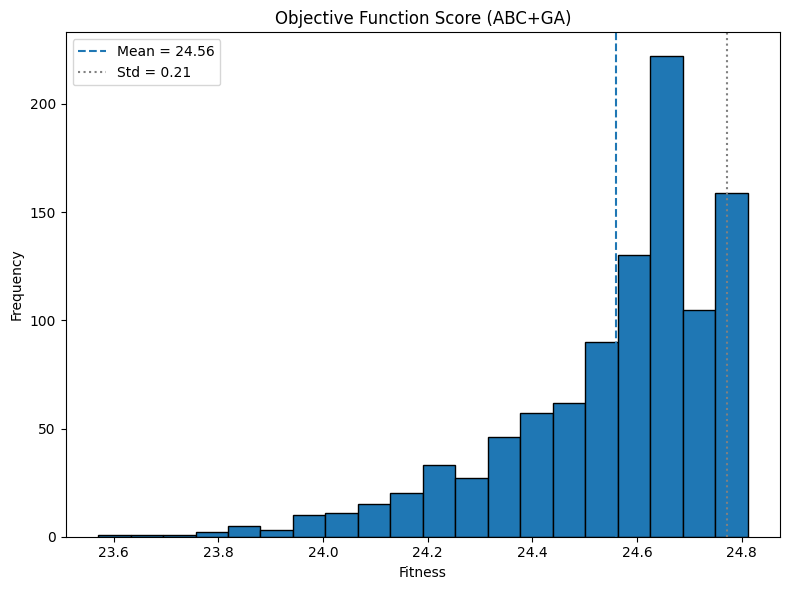

Mean fitness: 24.5596
Std deviation of fitness: 0.2118


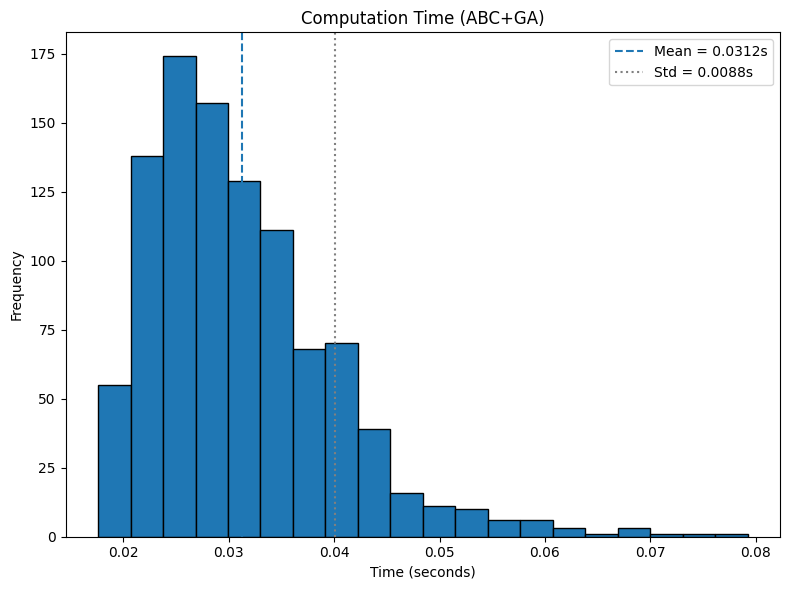

Mean computation time: 0.0312 seconds
Std deviation of time: 0.0088 seconds


(np.float64(24.559612015866545),
 np.float64(0.21179728538412296),
 np.float64(0.03122869277000427),
 np.float64(0.008812770263689308))

In [6]:
plot_distributions(onlooker_bee=10, trial_limit=10, num_of_cycle=30, switch_trial=10, crossover_trial=10)